In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from spatial_manifolds.detect_grids import (
    cell_classification_of1,
    compute_of_tcs,
    plot_vr_rate_map_trials_ax,
)

mouse_days = {
    25: [25],
}

# Storage for three classification schemes:
#   s1 - classified by OF1, rate maps from OF1
#   s2 - classified by OF2, rate maps from OF2
#   sc - combined (OF1∪OF2): one map per unique cell (best grid score wins)

def _empty_scheme():
    return dict(gcs_rows=[], ngs_rows=[], gc_maps=[], ngs_maps=[])

s1 = _empty_scheme()
s2 = _empty_scheme()
sc = _empty_scheme()

def _fill_maps(cells_df, tcs, out_list):
    for _, row in cells_df.iterrows():
        cid = int(row['cluster_id'])
        if cid in tcs:
            out_list.append(tcs[cid])

def _fill_maps_best_score(cells_df, tcs_of1, tcs_of2, ref_df1, ref_df2, out_list):
    """One map per cell: pick from whichever session has the higher grid score."""
    gs1 = ref_df1.set_index('cluster_id')['grid_score'] if len(ref_df1) > 0 else pd.Series(dtype=float)
    gs2 = ref_df2.set_index('cluster_id')['grid_score'] if len(ref_df2) > 0 else pd.Series(dtype=float)
    for _, row in cells_df.iterrows():
        cid = int(row['cluster_id'])
        score1 = gs1.get(cid, -np.inf)
        score2 = gs2.get(cid, -np.inf)
        if score1 >= score2 and cid in tcs_of1:
            out_list.append(tcs_of1[cid])
        elif cid in tcs_of2:
            out_list.append(tcs_of2[cid])
        elif cid in tcs_of1:
            out_list.append(tcs_of1[cid])

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing M{mouse} D{day:02}...")

        try:
            gcs_1, ngs_1, _, _, _, _ = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF1',
            )
        except FileNotFoundError:
            gcs_1, ngs_1 = pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF1 files.")

        try:
            gcs_2, ngs_2, _, _, _, _ = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF2',
            )
        except FileNotFoundError:
            gcs_2, ngs_2 = pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF2 files.")

        if len(gcs_1) == 0 and len(gcs_2) == 0:
            print(f"  No grid cells in either OF session, skipping.")
            continue

        shift_1 = gcs_1.travel.iloc[0] if len(gcs_1) > 0 else (gcs_2.travel.iloc[0] if len(gcs_2) > 0 else 0)
        shift_2 = gcs_2.travel.iloc[0] if len(gcs_2) > 0 else shift_1

        try:
            tcs_of1, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_1, session='OF1',
            )
        except Exception as e:
            print(f"  OF1 maps failed: {e}")
            tcs_of1 = {}

        try:
            tcs_of2, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_2, session='OF2',
            )
        except Exception as e:
            print(f"  OF2 maps failed: {e}")
            tcs_of2 = {}

        # --- Scheme 1: OF1 ---
        if len(gcs_1) > 0:
            s1['gcs_rows'].append(gcs_1)
            _fill_maps(gcs_1, tcs_of1, s1['gc_maps'])
        if len(ngs_1) > 0:
            s1['ngs_rows'].append(ngs_1)
            _fill_maps(ngs_1, tcs_of1, s1['ngs_maps'])

        # --- Scheme 2: OF2 ---
        if len(gcs_2) > 0:
            s2['gcs_rows'].append(gcs_2)
            _fill_maps(gcs_2, tcs_of2, s2['gc_maps'])
        if len(ngs_2) > 0:
            s2['ngs_rows'].append(ngs_2)
            _fill_maps(ngs_2, tcs_of2, s2['ngs_maps'])

        # --- Scheme 3: combined (OF1 ∪ OF2) ---
        # GCS = any cell GCS in OF1 OR OF2; one map per cell (best grid score wins)
        # NGS = any cell NGS in OF1 OR OF2 but NOT GCS in either; one map per cell (best grid score wins)
        gc1_ids = set(gcs_1['cluster_id'].tolist()) if len(gcs_1) > 0 else set()
        gc2_ids = set(gcs_2['cluster_id'].tolist()) if len(gcs_2) > 0 else set()
        combined_gc_ids = gc1_ids | gc2_ids

        gc_parts = [df for df in [gcs_1, gcs_2] if len(df) > 0]
        if gc_parts:
            gcs_comb = pd.concat(gc_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            sc['gcs_rows'].append(gcs_comb)
            _fill_maps_best_score(gcs_comb, tcs_of1, tcs_of2, gcs_1, gcs_2, sc['gc_maps'])

        ngs_parts = [df for df in [ngs_1, ngs_2] if len(df) > 0]
        if ngs_parts:
            ngs_comb_all = pd.concat(ngs_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            ngs_comb = ngs_comb_all[~ngs_comb_all['cluster_id'].isin(combined_gc_ids)]
            if len(ngs_comb) > 0:
                sc['ngs_rows'].append(ngs_comb)
                _fill_maps_best_score(ngs_comb, tcs_of1, tcs_of2, ngs_1, ngs_2, sc['ngs_maps'])

# Finalise DataFrames
for s in [s1, s2, sc]:
    s['gcs_all'] = pd.concat(s['gcs_rows'], ignore_index=True) if s['gcs_rows'] else pd.DataFrame()
    s['ngs_all'] = pd.concat(s['ngs_rows'], ignore_index=True) if s['ngs_rows'] else pd.DataFrame()

print(f"OF1  - GC: {len(s1['gc_maps'])}, NGS: {len(s1['ngs_maps'])}")
print(f"OF2  - GC: {len(s2['gc_maps'])}, NGS: {len(s2['ngs_maps'])}")
print(f"Comb - GC: {len(sc['gc_maps'])}, NGS: {len(sc['ngs_maps'])}")


Processing M25 D25...
OF1  - GC: 33, NGS: 56
OF2  - GC: 28, NGS: 52
Comb - GC: 44, NGS: 49


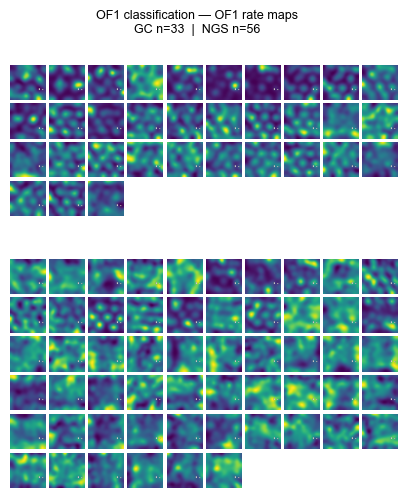

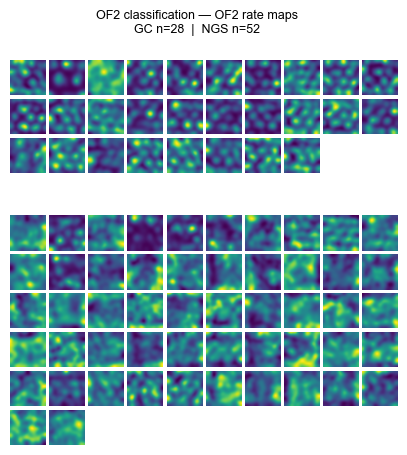

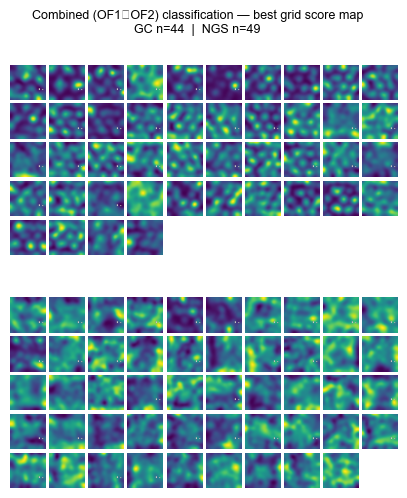

In [13]:
def plot_gc_and_ngs_of_rate_maps(
    gc_maps,
    ngs_maps,
    title="Grid cells (top) / NGS cells (bottom)",
    max_per_row=10,
    save_path=None,
):
    n_gc = len(gc_maps)
    n_ngs = len(ngs_maps)

    if n_gc == 0 or n_ngs == 0:
        print(f"Need at least one GC and one NGS cell. GC={n_gc}, NGS={n_ngs}")
        return

    rows_gc  = max(int(np.ceil(n_gc  / max_per_row)), 1)
    rows_ngs = max(int(np.ceil(n_ngs / max_per_row)), 1)
    ncols = max(int(np.ceil(n_gc / rows_gc)), int(np.ceil(n_ngs / rows_ngs)))

    spacer_rows = 1
    nrows_total = rows_gc + spacer_rows + rows_ngs

    fig, axes = plt.subplots(nrows_total, ncols,
                             figsize=(ncols * 0.5, nrows_total * 0.5), squeeze=False)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    def _plot_block(maps, row_start):
        for idx, rm in enumerate(maps):
            r = row_start + idx // ncols
            c = idx % ncols
            if r >= nrows_total:
                break
            axes[r, c].imshow(rm, cmap="viridis", origin="lower")
            axes[r, c].axis("off")

    _plot_block(gc_maps,  row_start=0)
    _plot_block(ngs_maps, row_start=rows_gc + spacer_rows)

    for r in range(nrows_total):
        for c in range(ncols):
            if len(axes[r, c].images) == 0:
                axes[r, c].axis("off")

    fig.suptitle(f"{title}\nGC n={n_gc}  |  NGS n={n_ngs}", fontsize=9)
    fig.tight_layout(rect=[0, 0, 0.3, 0.3])

    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()


base = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_0_classification/"

# --- Plot 1: OF1 classification, OF1 rate maps ---
plot_gc_and_ngs_of_rate_maps(
    s1['gc_maps'], s1['ngs_maps'],
    title="OF1 classification — OF1 rate maps",
    save_path=base + "of1_classification_of1_maps.pdf",
)

# --- Plot 2: OF2 classification, OF2 rate maps ---
plot_gc_and_ngs_of_rate_maps(
    s2['gc_maps'], s2['ngs_maps'],
    title="OF2 classification — OF2 rate maps",
    save_path=base + "of2_classification_of2_maps.pdf",
)

# --- Plot 3: combined (OF1 ∪ OF2) classification — best grid score map per cell ---
plot_gc_and_ngs_of_rate_maps(
    sc['gc_maps'], sc['ngs_maps'],
    title="Combined (OF1∪OF2) classification — best grid score map",
    save_path=base + "combined_classification_best_score_maps.pdf",
)
